# Carver Trend Engine - a layer-by-layer build (QQQ)

**One asset, daily bars, long-only.** This notebook rebuilds the Carver forecast
engine one layer at a time. Each layer gets: the theory, a pure forecast
function, a *calibration check*, and an **isolated backtest** so you can watch
how that single rule behaves before anything is combined. The last sections
combine the rules, size the position, add the FTI overlay, and assemble the
whole engine.

**Data.** Defaults to QQQ daily. The loader tries `yfinance` and falls back
to a reproducible synthetic series so the notebook always runs. For real data:
`pip install yfinance`, then it is automatic.

**The spine (why this order).** Normalise risk first -> build forecasts in
risk-adjusted units -> scale each to a common strength (|forecast| ~ 10) ->
combine with a diversification multiplier -> size to a vol target -> overlay.

> Outputs shown here were produced on the *synthetic fallback*. Re-run with
> `yfinance` installed to see real QQQ numbers.

## 0 - Setup: imports, data, and the shared engine

These cells define everything reused by every layer - data, the volatility
stack, forecast->position sizing, the long-only backtest, and the metrics. Run
them once, top to bottom.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----- global Carver constants -----
ANN_DAYS   = 252      # equities trade ~252 trading days/yr (365 for 24/7 crypto)
FC_TARGET  = 10.0     # forecast of 10 -> full vol-target position
FC_CAP     = 20.0     # forecasts clipped to +/- 2x the target
COST_BPS   = 3.25     # per-trade cost, bps (matches the Pine commission 0.0325%)
VOL_TARGET = 0.20     # portfolio vol target used in sizing

# daily EWMAC speed pairs + per-pair scalars (scalars make |forecast| ~ 10), and FDMs
EWMAC_PAIRS = [(8, 32, 5.95), (16, 64, 4.10), (32, 128, 2.79), (64, 256, 1.91)]
EWMAC_FDM   = 1.13

In [2]:
def load_prices(source="auto", symbol="QQQ", start="2000-01-01", csv_path=None, seed=7):
    """Daily close Series. 'auto' tries yfinance, else a synthetic QQQ-like equity series."""
    if source in ("auto", "yfinance"):
        try:
            import yfinance as yf
            df = yf.download(symbol, start=start, auto_adjust=True, progress=False)
            close = df["Close"]
            if isinstance(close, pd.DataFrame):
                close = close.iloc[:, 0]
            close = close.dropna(); close.index = pd.to_datetime(close.index); close.name = "close"
            if len(close) > 50:
                return close
            raise RuntimeError("empty result")
        except Exception as e:
            if source == "yfinance":
                raise
            print(f"[load_prices] yfinance unavailable ({e!r}) -> synthetic series.")
    if source == "csv":
        df = pd.read_csv(csv_path)
        dc = next((c for c in df.columns if c.lower() in ("date", "time", "timestamp")), None)
        if dc is not None:
            df = df.set_index(pd.to_datetime(df[dc]))
        close = (df["close"] if "close" in df else df["Close"]).dropna(); close.name = "close"
        return close
    return _synthetic_prices(seed=seed)

def _synthetic_prices(n=5000, seed=7, s0=100.0):
    """3-state Markov regime (bull/bear/chop) with persistent vol clustering."""
    rng = np.random.default_rng(seed)
    P = np.array([[0.985, 0.005, 0.010], [0.030, 0.945, 0.025], [0.020, 0.020, 0.960]])
    mu = np.array([0.0008, -0.0011, 0.0001]); bvol = np.array([0.0075, 0.022, 0.009])
    st, logp, h, out = 0, np.log(s0), 0.0, []
    for _ in range(n):
        st = rng.choice(3, p=P[st]); h = 0.94 * h + 0.06 * rng.normal()
        logp += mu[st] + bvol[st] * np.exp(0.5 * h) * rng.normal(); out.append(np.exp(logp))
    idx = pd.date_range(end=pd.Timestamp.today().normalize(), periods=n, freq="B")
    return pd.Series(out, index=idx, name="close")

In [3]:
def ewm_std(x, span):
    """Carver bias-corrected EWM std (matches the Pine engine)."""
    a = 2.0 / (span + 1.0)
    m  = x.ewm(alpha=a, adjust=False).mean()
    m2 = (x * x).ewm(alpha=a, adjust=False).mean()
    var = (m2 - m * m).clip(lower=0.0)
    bc = (2.0 - 2.0 * a) / (2.0 - a)
    return np.sqrt(var / bc)

def vol_stack(close, ann_days=ANN_DAYS, short_span=30, anchor_years=5,
              anchor_min_years=1, short_w=0.70, long_w=0.30):
    """ret, vol_short, vol_long, blended vol (annualised), and sigma_p
    (per-bar price-units sigma = the EWMAC denominator)."""
    ann = np.sqrt(ann_days)
    ret = close.pct_change().clip(-0.9, 9.0)                       # winsorised
    vol_short = ewm_std(ret, short_span) * ann
    vol_long  = vol_short.rolling(anchor_years * ann_days,
                                  min_periods=anchor_min_years * ann_days).mean()
    vol = pd.Series(np.where(vol_long.isna(), vol_short, short_w * vol_short + long_w * vol_long),
                    index=close.index, name="vol")
    sigma_p = (close * vol / ann).rename("sigma_p")
    return pd.DataFrame({"ret": ret, "vol_short": vol_short, "vol_long": vol_long,
                         "vol": vol, "sigma_p": sigma_p})

In [4]:
def clip_fc(f, cap=FC_CAP):
    return f.clip(-cap, cap)

def position_from_forecast(forecast, vol, vol_target=VOL_TARGET, fc_target=FC_TARGET, long_only=True):
    """weight = (forecast / 10) * (vol_target / vol), clipped [0,1] long-only.
    Clipping the position at 0 == flooring the forecast at 0, so a bipolar
    forecast still gives the production long-only position."""
    w = (forecast / fc_target) * (vol_target / vol)
    w = w.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return w.clip(0.0 if long_only else -1.0, 1.0).rename("weight")

def backtest(close, weight, cost_bps=COST_BPS, exec_lag=1):
    """held = weight.shift(1): decide at the close, act next bar (no look-ahead)."""
    ret = close.pct_change().fillna(0.0)
    held = weight.shift(exec_lag).fillna(0.0)
    turnover = held.diff().abs().fillna(held.abs())
    net = held * ret - turnover * (cost_bps / 1e4)
    return pd.DataFrame({"ret": ret, "weight": weight, "held": held,
                         "net": net, "equity": (1.0 + net).cumprod()})

def sharpe(net, ann_days=ANN_DAYS, rf=0.0):
    ex = net - rf / ann_days; sd = ex.std(ddof=1)
    return float("nan") if not sd else float(ex.mean() / sd * np.sqrt(ann_days))
def cagr(eq):
    eq = eq.dropna()
    if len(eq) < 2 or eq.iloc[-1] <= 0: return float("nan")
    yrs = (eq.index[-1] - eq.index[0]).days / 365.25
    return float(eq.iloc[-1] ** (1 / yrs) - 1) if yrs > 0 else float("nan")
def max_dd(eq):
    eq = eq.dropna(); return float((eq / eq.cummax() - 1).min()) if len(eq) else float("nan")
def ann_turnover(held, ann_days=ANN_DAYS):
    yrs = len(held) / ann_days; return float(held.diff().abs().sum() / yrs) if yrs > 0 else float("nan")

def report(name, res):
    print(f"{name:24s} Sharpe {sharpe(res['net']):5.2f}   CAGR {cagr(res['equity'])*100:6.1f}%"
          f"   MaxDD {max_dd(res['equity'])*100:6.1f}%   Turn {ann_turnover(res['held']):4.1f}x")

In [5]:
close = load_prices()          # QQQ daily (synthetic fallback when offline)
vs = vol_stack(close)
bh = (close / close.iloc[0]).rename("buy_hold")
print(f"{close.index[0].date()} -> {close.index[-1].date()}  ({len(close)} daily bars)   "
      f"mean ann vol {vs['vol'].mean()*100:.0f}%")

[load_prices] yfinance unavailable (ModuleNotFoundError("No module named 'yfinance'")) -> synthetic series.
2007-04-18 -> 2026-06-16  (5000 daily bars)   mean ann vol 16%


## Layer 0 - Returns & the volatility stack

Before any forecast exists, Carver fixes the *unit problem*. A 32-day EMA
crossover at \$40 and at \$500 is not the same bet - the dollar gap scales with
price and with how violent the tape is. So every forecast divides by
$\sigma_p$, a per-bar estimate of how far price usually moves. That turns raw
price distance into **risk distance**, comparable across price and regime.

$$\text{vol} = 0.70\,\text{vol}_{\text{short}} + 0.30\,\text{vol}_{\text{long}},
\qquad \sigma_p = \text{close}\cdot \text{vol}/\sqrt{\text{annDays}}$$

`vol_short` (30-span EWM std, annualised) reacts; `vol_long` (~5y mean) anchors.
The blend reacts *but stays anchored*. The diagnostic that matters: divide
returns by their own daily vol and the spread should be roughly constant
through time - that homoscedasticity is exactly what makes a $\sigma_p$-based
forecast stationary. (This layer is infrastructure, so there is no equity curve
yet.)

risk-normalised return std (target ~1.0): 0.98


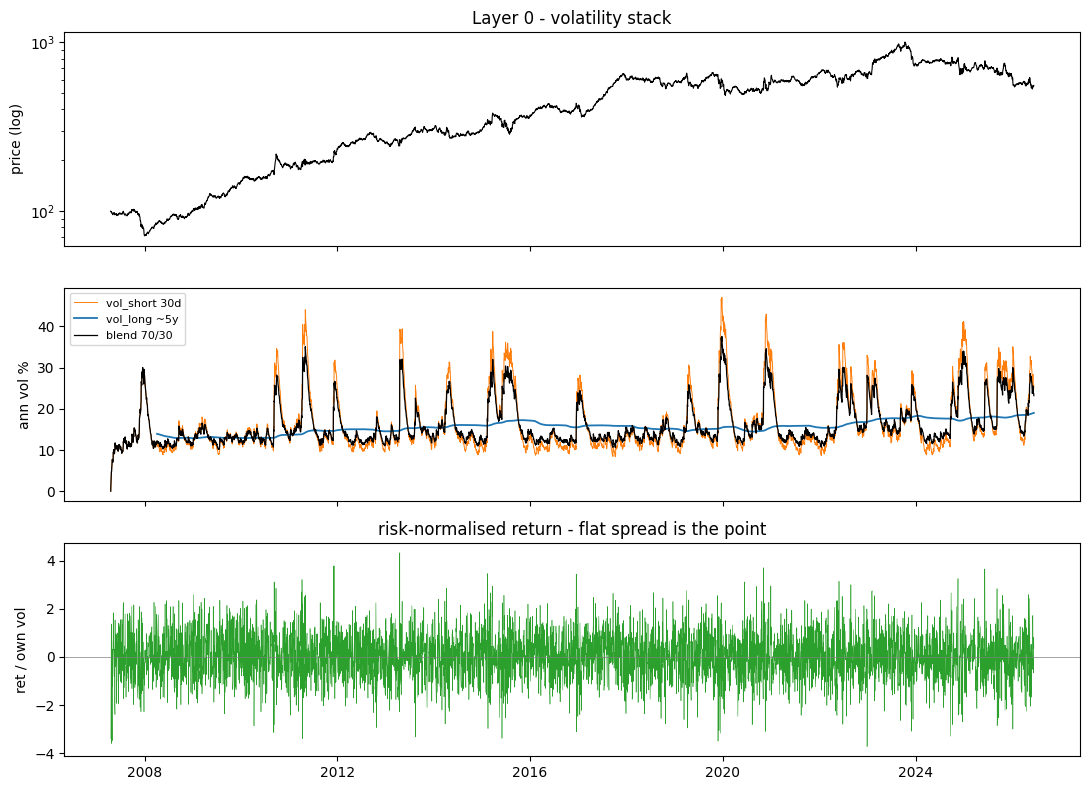

In [6]:
ann = np.sqrt(ANN_DAYS)
risk_norm = (vs["ret"] / (vs["vol"] / ann)).replace([np.inf, -np.inf], np.nan)
print(f"risk-normalised return std (target ~1.0): {risk_norm.std():.2f}")

fig, ax = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
ax[0].plot(close.index, close, "k", lw=0.8); ax[0].set_yscale("log")
ax[0].set_ylabel("price (log)"); ax[0].set_title("Layer 0 - volatility stack")
ax[1].plot(vs.index, vs.vol_short * 100, lw=0.7, color="tab:orange", label="vol_short 30d")
ax[1].plot(vs.index, vs.vol_long  * 100, lw=1.3, color="tab:blue",   label="vol_long ~5y")
ax[1].plot(vs.index, vs.vol       * 100, lw=0.9, color="k",          label="blend 70/30")
ax[1].set_ylabel("ann vol %"); ax[1].legend(fontsize=8)
ax[2].plot(risk_norm.index, risk_norm, lw=0.4, color="tab:green"); ax[2].axhline(0, color="gray", lw=0.5)
ax[2].set_ylabel("ret / own vol"); ax[2].set_title("risk-normalised return - flat spread is the point")
plt.tight_layout(); plt.show()

**Observe:** `vol_long` is a smooth floor/ceiling; `vol_short` spikes
through it. The bottom panel does not fan in and out - raw returns would. That
flatness is why dividing trend signals by $\sigma_p$ works.

## Layer 1 - EWMAC (the trend backbone)

For one speed pair, $\text{raw} = (\text{EMA}_{\text{fast}} - \text{EMA}_{\text{slow}})/\sigma_p$
- a risk-scaled trend. We run four pairs (8/32, 16/64, 32/128, 64/256) to
diversify across trend *speed*, scale each so $|\text{forecast}|\approx 10$,
clip to $\pm20$, average, and apply a small within-family FDM (1.13).

**Calibration is the heart of this lesson.** The scalars exist only to make the
average absolute forecast land near 10, because sizing reads "10 = full
position". We print $\text{mean}(|f|)$ - far from 10 means refit
($\text{scalar} = 10/\text{mean}(|\text{raw}|)$). The forecast is bipolar so you
can see it flip negative; the long-only position simply goes flat there.

EWMAC calibration: mean(|f|) = 9.4   (target ~10)
EWMAC long-only          Sharpe  0.65   CAGR    6.7%   MaxDD  -25.7%   Turn  4.3x


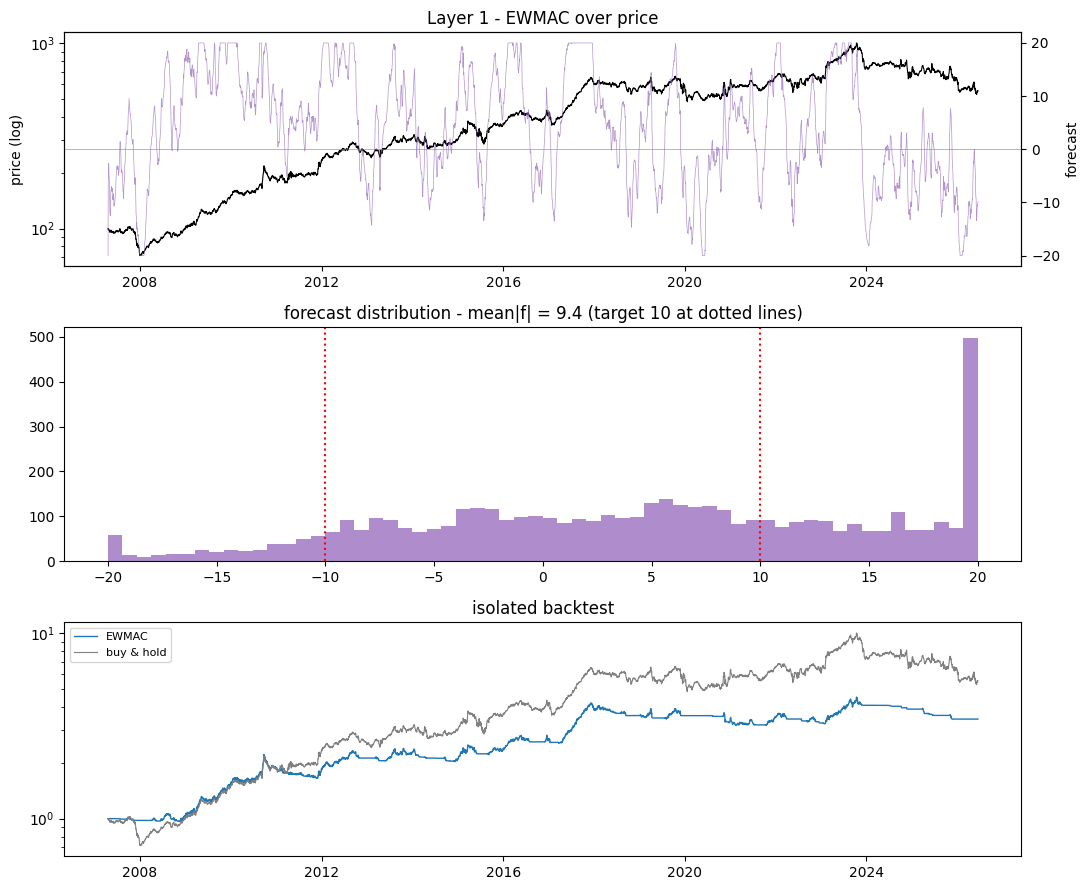

In [7]:
def ewmac_forecast(close, sigma_p, pairs=EWMAC_PAIRS, fdm=EWMAC_FDM, cap=FC_CAP):
    subs = []
    for f, s, sc in pairs:
        raw = (close.ewm(span=f, adjust=False).mean() - close.ewm(span=s, adjust=False).mean()) / sigma_p
        subs.append((raw * sc).clip(-cap, cap))
    return (sum(subs) / len(subs) * fdm).clip(-cap, cap)

ew = ewmac_forecast(close, vs.sigma_p)
print(f"EWMAC calibration: mean(|f|) = {ew.abs().mean():.1f}   (target ~10)")
res_ew = backtest(close, position_from_forecast(ew, vs.vol))
report("EWMAC long-only", res_ew)

fig, ax = plt.subplots(3, 1, figsize=(11, 9))
ax[0].plot(close.index, close, "k", lw=0.8); ax[0].set_yscale("log"); ax[0].set_ylabel("price (log)")
axt = ax[0].twinx(); axt.plot(ew.index, ew, color="tab:purple", lw=0.5, alpha=0.7)
axt.axhline(0, color="gray", lw=0.4); axt.set_ylabel("forecast"); ax[0].set_title("Layer 1 - EWMAC over price")
ax[1].hist(ew.dropna(), bins=60, color="tab:purple", alpha=0.75)
for x in (-10, 10): ax[1].axvline(x, color="red", ls=":")
ax[1].set_title(f"forecast distribution - mean|f| = {ew.abs().mean():.1f} (target 10 at dotted lines)")
ax[2].plot(res_ew.index, res_ew.equity, color="tab:blue", lw=1.0, label="EWMAC")
ax[2].plot(bh.index, bh, color="gray", lw=0.8, label="buy & hold"); ax[2].set_yscale("log")
ax[2].legend(fontsize=8); ax[2].set_title("isolated backtest"); plt.tight_layout(); plt.show()

**Observe:** the forecast pins near +20 in strong uptrends and flips hard
negative in selloffs. Equity is smoother through chop than buy-and-hold but
cedes the V-bottoms it sits out - the trend-following trade-off.

## Layer 2 - Breakout

Where does price sit inside its recent range?
$\text{spir} = (\text{close}-\min_n)/(\max_n-\min_n)$, centred and scaled to
forecast units, EMA-smoothed, over four lookbacks (40/80/160/320). Intuitively a
different idea from EWMAC - and the punchline is that it is *not a different
bet*. We measure its correlation to EWMAC; high correlation means breakout buys
you almost no diversification over the trend you already own.

Breakout calibration: mean(|f|) = 7.2
corr(EWMAC, Breakout) = 0.96   <- 'different formula, same bet?'
Breakout long-only       Sharpe  0.78   CAGR    7.6%   MaxDD  -26.6%   Turn  3.8x


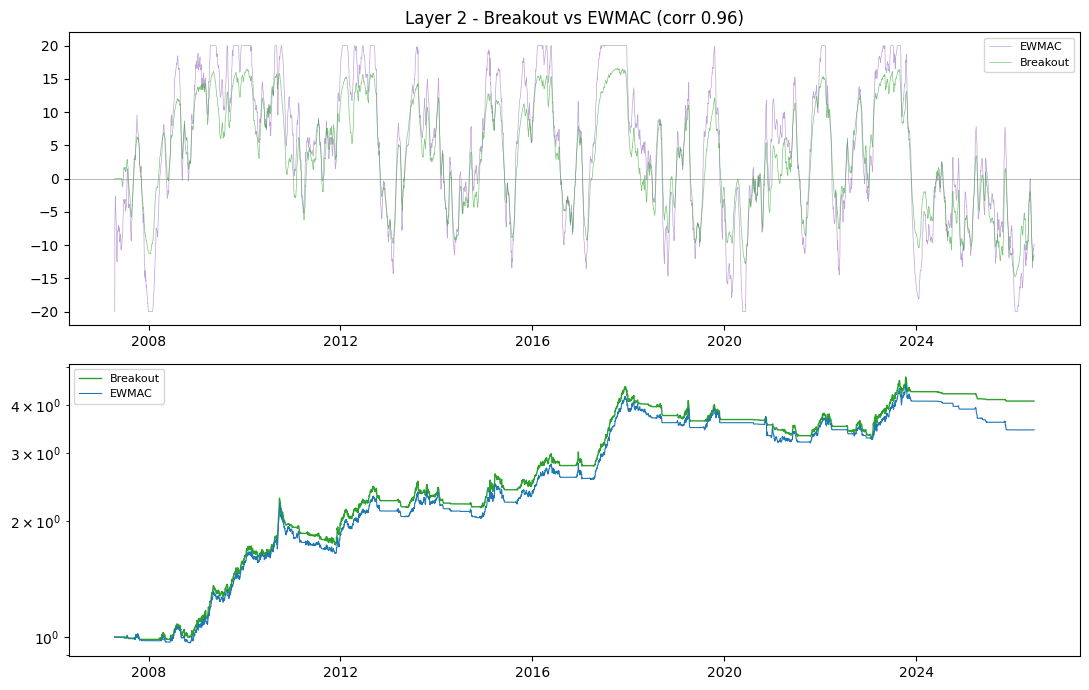

In [8]:
def breakout_single(close, n, sc, sm, cap=FC_CAP):
    mn, mx = close.rolling(n).min(), close.rolling(n).max(); rng = mx - mn
    spir = ((close - mn) / rng).where(rng > 0, 0.5)
    return ((spir - 0.5) * 40.0).ewm(span=sm, adjust=False).mean().mul(sc).clip(-cap, cap)

def breakout_forecast(close, fdm=1.17, cap=FC_CAP):
    P = [(40, 0.70, 10), (80, 0.73, 20), (160, 0.74, 40), (320, 0.74, 80)]
    subs = [breakout_single(close, n, sc, sm) for n, sc, sm in P]
    return (sum(subs) / len(subs) * fdm).clip(-cap, cap)

br = breakout_forecast(close)
print(f"Breakout calibration: mean(|f|) = {br.abs().mean():.1f}")
print(f"corr(EWMAC, Breakout) = {ew.corr(br):.2f}   <- 'different formula, same bet?'")
res_br = backtest(close, position_from_forecast(br, vs.vol))
report("Breakout long-only", res_br)

fig, ax = plt.subplots(2, 1, figsize=(11, 7))
ax[0].plot(ew.index, ew, color="tab:purple", lw=0.5, alpha=0.6, label="EWMAC")
ax[0].plot(br.index, br, color="tab:green", lw=0.5, alpha=0.6, label="Breakout")
ax[0].axhline(0, color="gray", lw=0.4); ax[0].legend(fontsize=8)
ax[0].set_title(f"Layer 2 - Breakout vs EWMAC (corr {ew.corr(br):.2f})")
ax[1].plot(res_br.index, res_br.equity, color="tab:green", lw=1.0, label="Breakout")
ax[1].plot(res_ew.index, res_ew.equity, color="tab:blue", lw=0.8, label="EWMAC")
ax[1].set_yscale("log"); ax[1].legend(fontsize=8); plt.tight_layout(); plt.show()

**Observe:** the two forecasts track each other closely. Breakout is a
trend cousin - useful as a mild smoother of EWMAC, not as an independent return
source.

## Layer 3 - Acceleration

The first difference of the *unclipped* EWMAC base over {8,16,32,64} bars - the
**second derivative** of price, i.e. is the trend itself speeding up or rolling
over. A "forecast of a forecast". It leads EWMAC at turns and is noisier, which
is exactly why its family FDM (1.55) is higher: the speed-variants of an
acceleration decorrelate more than EWMAC's levels do.

Accel calibration: mean(|f|) = 9.2   corr(EWMAC, Accel) = 0.57
Acceleration long-only   Sharpe  0.55   CAGR    4.9%   MaxDD  -32.4%   Turn 10.3x


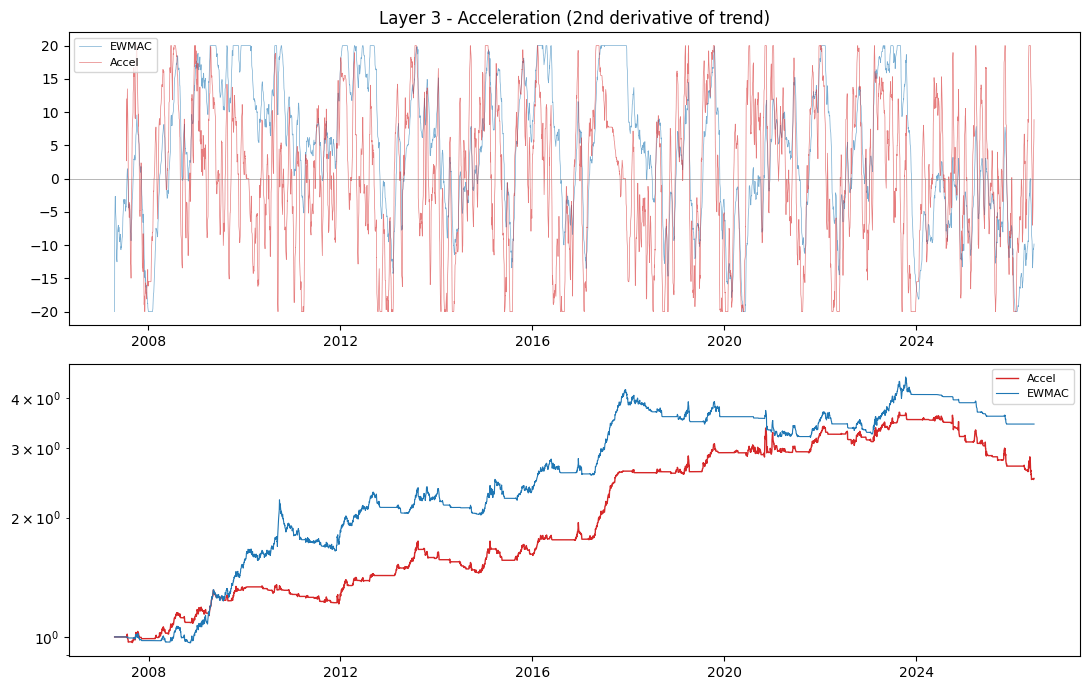

In [9]:
def ewmac_base(close, sigma_p, f, s, sc, cap=FC_CAP):
    return ((close.ewm(span=f, adjust=False).mean()
             - close.ewm(span=s, adjust=False).mean()) / sigma_p * sc).clip(-cap, cap)

def accel_forecast(close, sigma_p, fdm=1.55, cap=FC_CAP):
    bases = [ewmac_base(close, sigma_p, f, s, sc) for f, s, sc in EWMAC_PAIRS]
    AP, SC = [8, 16, 32, 64], [1.87, 1.90, 1.98, 2.05]
    subs = [((bases[i] - bases[i].shift(AP[i])) * SC[i]).clip(-cap, cap) for i in range(4)]
    return (sum(subs) / len(subs) * fdm).clip(-cap, cap)

ac = accel_forecast(close, vs.sigma_p)
print(f"Accel calibration: mean(|f|) = {ac.abs().mean():.1f}   corr(EWMAC, Accel) = {ew.corr(ac):.2f}")
res_ac = backtest(close, position_from_forecast(ac, vs.vol))
report("Acceleration long-only", res_ac)

fig, ax = plt.subplots(2, 1, figsize=(11, 7))
ax[0].plot(ew.index, ew, color="tab:blue", lw=0.5, alpha=0.6, label="EWMAC")
ax[0].plot(ac.index, ac, color="tab:red", lw=0.5, alpha=0.6, label="Accel"); ax[0].axhline(0, color="gray", lw=0.4)
ax[0].legend(fontsize=8); ax[0].set_title("Layer 3 - Acceleration (2nd derivative of trend)")
ax[1].plot(res_ac.index, res_ac.equity, color="tab:red", lw=1.0, label="Accel")
ax[1].plot(res_ew.index, res_ew.equity, color="tab:blue", lw=0.8, label="EWMAC")
ax[1].set_yscale("log"); ax[1].legend(fontsize=8); plt.tight_layout(); plt.show()

**Observe:** acceleration flips earlier and more often than EWMAC - it is
the most whipsaw-prone trend variant on its own, and earns its place mainly
through low correlation, not standalone Sharpe.

## Layer 4 - Skew (the diversifier)

The only rule here that is **not** a trend measure. Compute bias-corrected
sample skewness $G_1$ of returns over {60,120,240} days, **negate** it, smooth,
scale. Negation means: go long assets whose returns are *negatively* skewed -
harvesting the premium paid to bear crash risk. This is where real orthogonality
to the trend trio comes from; watch its correlation to EWMAC versus the others.

Skew calibration: mean(|f|) = 9.5   corr(EWMAC, Skew) = -0.33  <- the diversifier
Skew long-only           Sharpe  0.44   CAGR    4.4%   MaxDD  -34.8%   Turn  2.1x


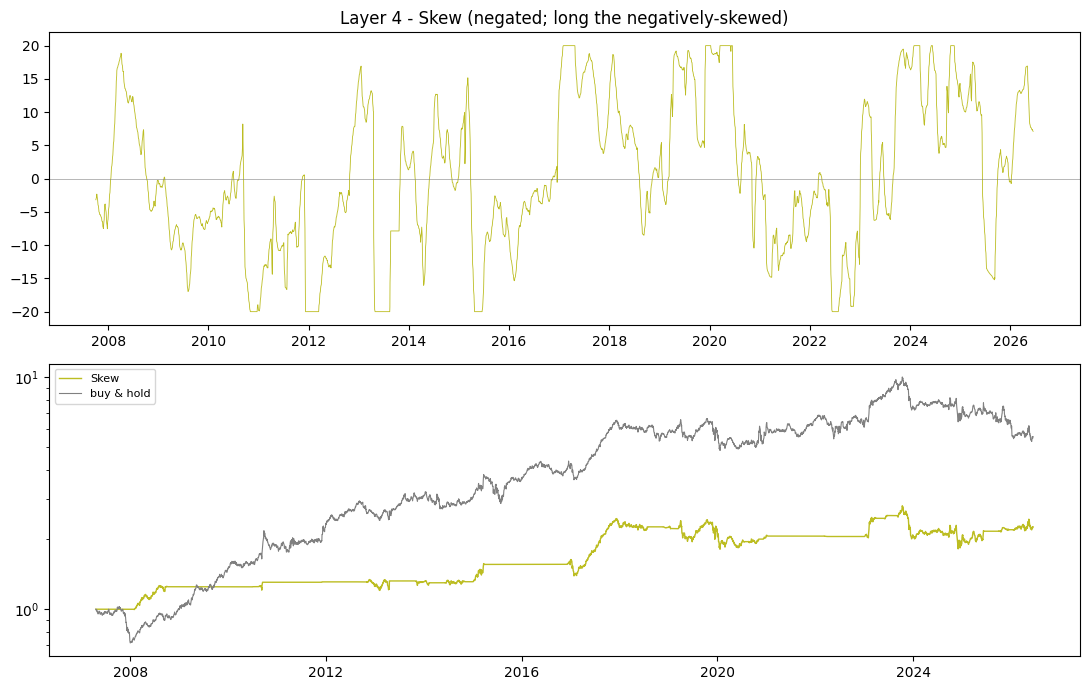

In [10]:
def skew_forecast(ret, fdm=1.18, cap=FC_CAP):
    P = [(60, 33.3, 15), (120, 37.2, 30), (240, 39.2, 60)]
    subs = []
    for w, sc, sm in P:
        g = ret.rolling(w, min_periods=w // 2).skew()           # bias-corrected G1
        subs.append((-g).ewm(span=sm, adjust=False).mean().mul(sc).clip(-cap, cap))
    return (sum(subs) / len(subs) * fdm).clip(-cap, cap)

sk = skew_forecast(vs.ret)
print(f"Skew calibration: mean(|f|) = {sk.abs().mean():.1f}   corr(EWMAC, Skew) = {ew.corr(sk):.2f}  <- the diversifier")
res_sk = backtest(close, position_from_forecast(sk, vs.vol))
report("Skew long-only", res_sk)

fig, ax = plt.subplots(2, 1, figsize=(11, 7))
ax[0].plot(sk.index, sk, color="tab:olive", lw=0.6); ax[0].axhline(0, color="gray", lw=0.4)
ax[0].set_title("Layer 4 - Skew (negated; long the negatively-skewed)")
ax[1].plot(res_sk.index, res_sk.equity, color="tab:olive", lw=1.0, label="Skew")
ax[1].plot(bh.index, bh, color="gray", lw=0.8, label="buy & hold"); ax[1].set_yscale("log")
ax[1].legend(fontsize=8); plt.tight_layout(); plt.show()

**Observe:** skew's correlation to EWMAC is far lower than breakout's or
acceleration's. Its standalone equity looks nothing like the trend rules - that
*difference* is its whole value in the combination.

## Layer 5 - Volatility attenuation

A regime multiplier on the *combined* forecast. Take the percentile rank of
current vol within its own history, $p_{\text{vol}}\in[0,1]$, then

$$\text{vol\_att} = \text{clip}(1.5 - p_{\text{vol}},\,[0.5,\,1.5]).$$

Calm regime ($p=0$) -> 1.5x; median ($p=0.5$) -> 1.0x; stormy ($p=1$) -> 0.5x.
It is **mean-neutral**: averaged over a uniform percentile it is exactly 1.0, so
it does not shift average exposure (it preserves the forecast calibration) - it
only *redistributes* risk across vol regimes. The quantile is EWMA-smoothed so
the multiplier does not churn the position. It rides on top of the $1/\text{vol}$
sizing as deliberate extra de-risking in storms.

EWMAC (no att)           Sharpe  0.65   CAGR    6.7%   MaxDD  -25.7%   Turn  4.3x
EWMAC x vol_att          Sharpe  0.71   CAGR    6.8%   MaxDD  -23.7%   Turn  4.2x


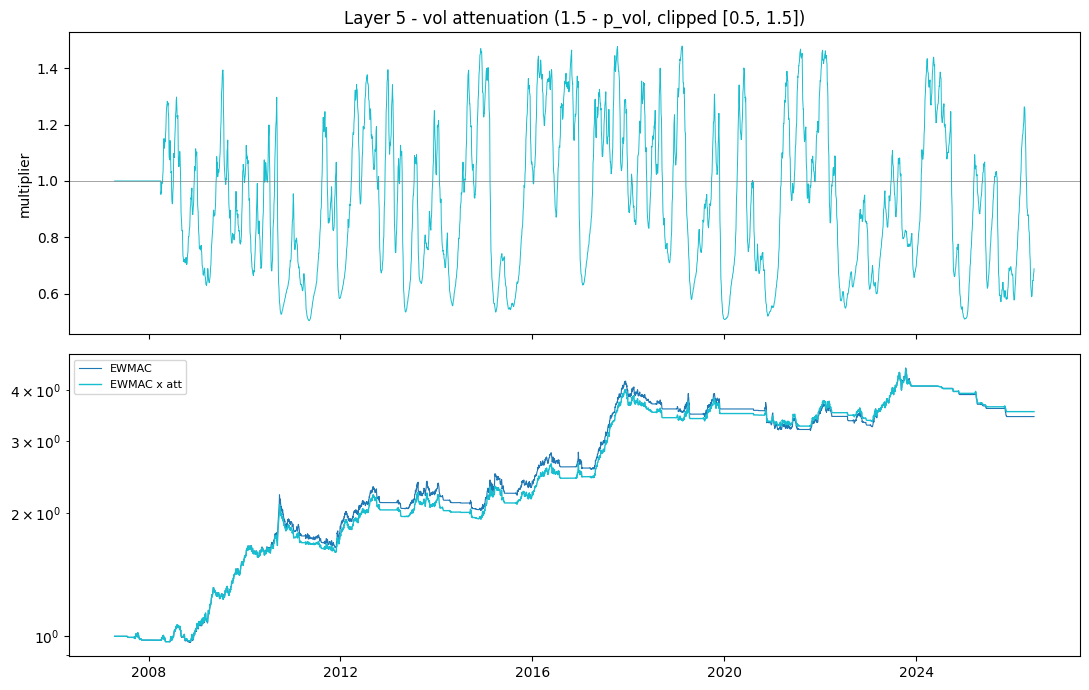

In [11]:
def vol_attenuation(vol, window=1260, smooth=10):
    p = vol.rolling(window, min_periods=252).rank(pct=True)
    p = p.ewm(span=smooth, adjust=False).mean()
    return (1.5 - p).clip(0.5, 1.5).fillna(1.0).rename("vol_att")

att = vol_attenuation(vs.vol)
res_ew_att = backtest(close, position_from_forecast(clip_fc(ew * att), vs.vol))
report("EWMAC (no att)", res_ew); report("EWMAC x vol_att", res_ew_att)

fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax[0].plot(att.index, att, color="tab:cyan", lw=0.7); ax[0].axhline(1, color="gray", lw=0.5)
ax[0].set_ylabel("multiplier"); ax[0].set_title("Layer 5 - vol attenuation (1.5 - p_vol, clipped [0.5, 1.5])")
ax[1].plot(res_ew.index, res_ew.equity, color="tab:blue", lw=0.8, label="EWMAC")
ax[1].plot(res_ew_att.index, res_ew_att.equity, color="tab:cyan", lw=1.0, label="EWMAC x att")
ax[1].set_yscale("log"); ax[1].legend(fontsize=8); plt.tight_layout(); plt.show()

**Observe:** the multiplier spends time both above and below 1.0 (the
mean-neutral design). Applied to EWMAC it trims exposure into high-vol stretches
and adds it in calm ones, reshaping the equity path without a systematic size
change.

## Layer 6 - Combining: weights and the FDM

The vote: $\text{combined} = (w_e\,\text{EWMAC} + w_b\,\text{Breakout} +
w_a\,\text{Accel} + w_s\,\text{Skew})\times \text{FDM}$, with weights
(0.15, 0.15, 0.15, 0.20) and FDM 1.55.

Two things to see. First the **correlation matrix** - the trend trio clusters,
skew sits apart. Second the **under-betting**: the weights sum to 0.65, and
$0.65\times1.55\approx1.01$, so the cross-rule FDM here is almost entirely
*renormalising the sub-1 weight sum* rather than adding diversification lift. A
true FDM on unit-sum weights at these correlations would be larger. The payoff
test: does the combined Sharpe beat the average of the four singles? That gap is
diversification, made visible.

forecast correlation matrix (active periods):
          EWMAC  Breakout  Accel  Skew
EWMAC      1.00      0.96   0.57 -0.33
Breakout   0.96      1.00   0.51 -0.32
Accel      0.57      0.51   1.00 -0.07
Skew      -0.33     -0.32  -0.07  1.00

combined mean(|f|) = 5.2   (weights sum 0.65 x FDM 1.55 = 1.01 -> near 1, little lift)
COMBINED (no att)        Sharpe  0.58   CAGR    4.8%   MaxDD  -27.1%   Turn  7.2x
avg Sharpe of the 4 singles = 0.60    combined Sharpe = 0.58


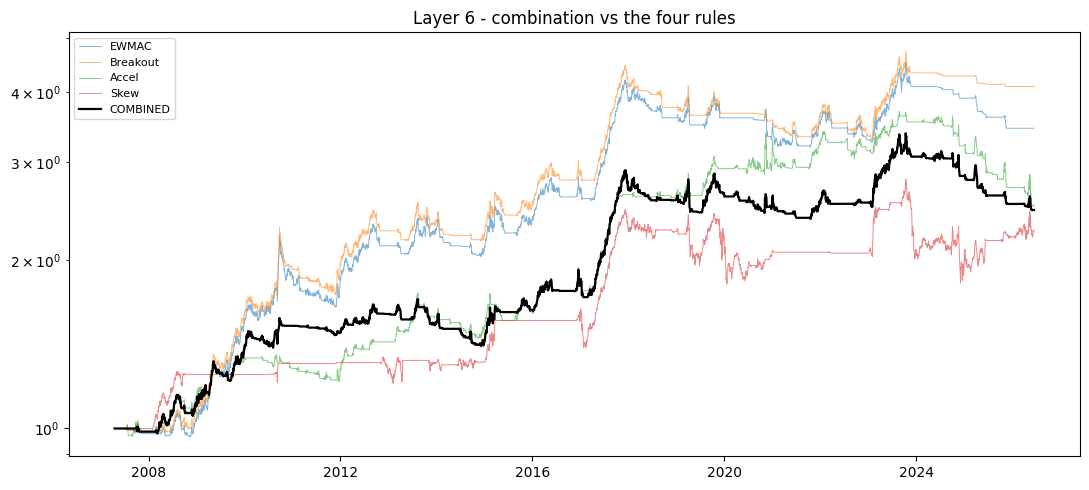

In [12]:
WEIGHTS, CARVER_FDM = (0.15, 0.15, 0.15, 0.20), 1.55
def combine_forecasts(ew, br, ac, sk, weights=WEIGHTS, fdm=CARVER_FDM, cap=FC_CAP):
    we, wb, wa, ws = weights
    return ((we * ew + wb * br + wa * ac + ws * sk) * fdm).clip(-cap, cap)

F = pd.concat([ew, br, ac, sk], axis=1); F.columns = ["EWMAC", "Breakout", "Accel", "Skew"]
print("forecast correlation matrix (active periods):")
print(F.dropna().corr().round(2).to_string())

combined = combine_forecasts(ew, br, ac, sk)
print(f"\ncombined mean(|f|) = {combined.abs().mean():.1f}   "
      f"(weights sum {sum(WEIGHTS):.2f} x FDM {CARVER_FDM} = {sum(WEIGHTS)*CARVER_FDM:.2f} -> near 1, little lift)")
res_comb = backtest(close, position_from_forecast(combined, vs.vol))

singles = {"EWMAC": res_ew, "Breakout": res_br, "Accel": res_ac, "Skew": res_sk}
avg_sr = float(np.mean([sharpe(r["net"]) for r in singles.values()]))
report("COMBINED (no att)", res_comb)
print(f"avg Sharpe of the 4 singles = {avg_sr:.2f}    combined Sharpe = {sharpe(res_comb['net']):.2f}")

fig, ax = plt.subplots(figsize=(11, 5))
for k, r in singles.items(): ax.plot(r.index, r.equity, lw=0.7, alpha=0.55, label=k)
ax.plot(res_comb.index, res_comb.equity, color="k", lw=1.6, label="COMBINED")
ax.set_yscale("log"); ax.legend(fontsize=8); ax.set_title("Layer 6 - combination vs the four rules")
plt.tight_layout(); plt.show()

**Observe:** combined Sharpe should sit above the simple average of the
singles whenever the rules are less than perfectly correlated - that is the
whole point of running four. If the lift looks small, the renormalised FDM is
why (see the weight-sum note).

## Layer 7 - Forecast -> position

$$w = \text{clip}\Big(\tfrac{\text{forecast}}{10}\cdot\tfrac{\text{volTarget}}{\text{vol}},\;[0,1]\Big)$$

A forecast of 10 at a vol equal to the target gives a 100% position; weaker
forecasts or higher vol shrink it. The $[0,1]$ cap is a capacity decision: in
strong, low-vol regimes the uncapped weight wants to exceed 1, and clipping it
gives up that upside in exchange for never levering. We show how often the cap
binds.

weight hits the 1.0 cap on 21% of bars (capacity given up in strong, low-vol regimes)


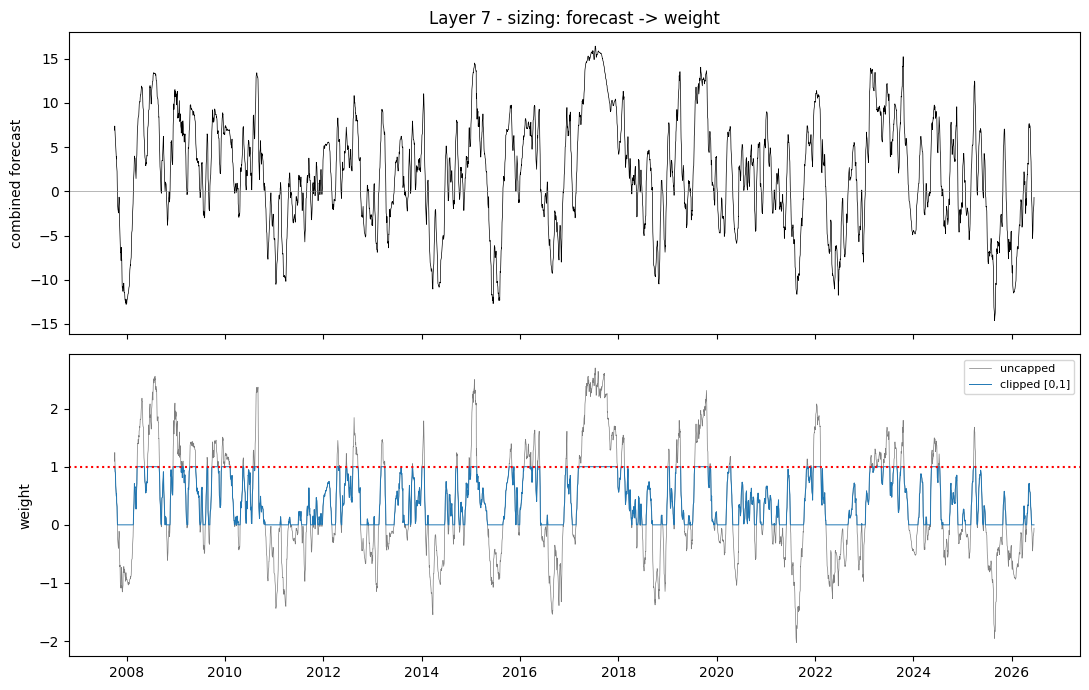

In [13]:
w_raw = (combined / FC_TARGET) * (VOL_TARGET / vs.vol)          # uncapped
w_cap = w_raw.clip(0, 1)
print(f"weight hits the 1.0 cap on {(w_raw > 1).mean()*100:.0f}% of bars "
      f"(capacity given up in strong, low-vol regimes)")

fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax[0].plot(combined.index, combined, color="k", lw=0.5); ax[0].axhline(0, color="gray", lw=0.4)
ax[0].set_ylabel("combined forecast"); ax[0].set_title("Layer 7 - sizing: forecast -> weight")
ax[1].plot(w_raw.index, w_raw, color="tab:gray", lw=0.5, label="uncapped")
ax[1].plot(w_cap.index, w_cap, color="tab:blue", lw=0.7, label="clipped [0,1]")
ax[1].axhline(1, color="red", ls=":"); ax[1].legend(fontsize=8); ax[1].set_ylabel("weight")
plt.tight_layout(); plt.show()

**Observe:** the clipped weight flat-tops at 1.0 during the strongest
trends. Every bar on that ceiling is forecast strength you are choosing not to
press - the long-only, no-leverage trade-off.

## Layer 8 - FTI overlay (advanced; not Carver-canonical)

A trend-*quality* gate of your own. Smooth price with a zero-phase windowed-sinc
FIR, segment it into directional **blocks** (a counter-move must persist
`min_block` bars to flip the block), then per block measure
$\text{signal} = |\text{filter now} - \text{filter at block start}|$ and
$\text{noise} = \overline{|\text{price} - \text{filter}|}$. Their ratio is an
efficiency-style cleanliness score; its percentile rank maps to a multiplier in
$[0.5, 1.5]$ - clean trends scale the position up, choppy ones down.

> Note: faithful to the Pine, the noise accumulator only resets on the first
> block out of flat, so it behaves as a long-run average after that. Flagged so
> the behaviour is not a surprise.

FTI multiplier: range [0.50, 1.50]  mean 1.06
Combined+att (no FTI)    Sharpe  0.64   CAGR    4.9%   MaxDD  -22.2%   Turn  6.9x
Combined+att x FTI       Sharpe  0.63   CAGR    4.7%   MaxDD  -20.5%   Turn  6.3x


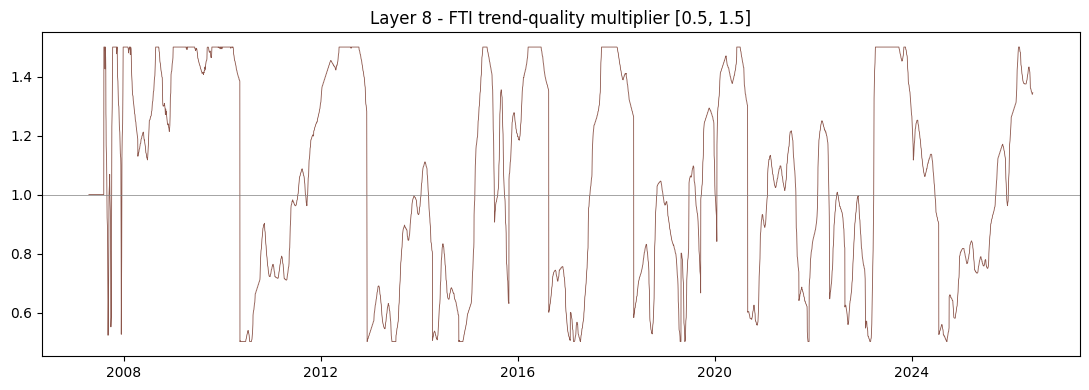

In [14]:
def fir_taps(hl, cutoff):
    n = 2 * hl + 1; fc = 1.0 / cutoff; i = np.arange(n); c = i - hl
    with np.errstate(divide="ignore", invalid="ignore"):
        sinc = np.where(c == 0, 2 * fc, np.sin(2 * np.pi * fc * c) / (np.pi * c))
    ham = 0.54 - 0.46 * np.cos(2 * np.pi * i / (n - 1)); t = sinc * ham
    return t / t.sum()

def fir_lagged(close, hl=25, cutoff=80):
    taps = fir_taps(hl, cutoff); n = len(taps); arr = close.values.astype(float)
    conv = np.convolve(arr, taps, mode="full")[:len(arr)]; conv[:n - 1] = np.nan
    return pd.Series(conv, index=close.index, name="filtered")

def fti_multiplier(close, hl=25, cutoff=80, min_block=40, warmup=10, crat_lb=504,
                   off=0.5, lo=0.5, hi=1.5):
    filt = fir_lagged(close, hl, cutoff); fv = filt.values; cl = close.values; n = len(fv)
    fdir = np.sign(np.diff(fv, prepend=np.nan)); fdir[np.isnan(fdir)] = 0
    live = np.full(n, np.nan)
    cbd = cdir = cbar = bib = 0; bsf = np.nan; ns = 0.0; nc = 0
    for t in range(n):
        if np.isnan(fv[t]):
            continue
        d = int(fdir[t])
        if cbd == 0:
            if d != 0: cbd = d; bib = 1; bsf = fv[t]
        elif d == cbd:
            cdir = 0; cbar = 0; bib += 1
        elif d == 0:
            bib += 1
        else:
            if cdir == d: cbar += 1
            else: cdir = d; cbar = 1
            bib += 1
            if cbar >= min_block:
                cbd = cdir; bib = cbar; j = t - (cbar - 1)
                bsf = fv[j] if j >= 0 else np.nan; cdir = 0; cbar = 0
        if cbd != 0:
            px = cl[t - hl] if t - hl >= 0 else np.nan
            if not np.isnan(px):
                if bib == 1: ns = abs(px - fv[t]); nc = 1
                else:        ns += abs(px - fv[t]); nc += 1
        nm = ns / nc if nc > 0 else np.nan
        sm = abs(fv[t] - bsf) if not np.isnan(bsf) else np.nan
        if bib >= warmup and not np.isnan(sm) and not np.isnan(nm) and nm > 0:
            live[t] = sm / nm
    live = pd.Series(live, index=close.index)
    crat = live.rolling(crat_lb, min_periods=20).rank(pct=True)
    return (off + crat).clip(lo, hi).fillna(1.0).rename("fti_mult"), live

fti_mult, _ = fti_multiplier(close)
print(f"FTI multiplier: range [{fti_mult.min():.2f}, {fti_mult.max():.2f}]  mean {fti_mult.mean():.2f}")
fc_att = clip_fc(combined * att)
w_no  = position_from_forecast(fc_att, vs.vol)
w_yes = (w_no * fti_mult).clip(0, 1)
report("Combined+att (no FTI)", backtest(close, w_no))
report("Combined+att x FTI",    backtest(close, w_yes))

fig, ax = plt.subplots(figsize=(11, 4)); ax.plot(fti_mult.index, fti_mult, color="tab:brown", lw=0.6)
ax.axhline(1, color="gray", lw=0.5); ax.set_title("Layer 8 - FTI trend-quality multiplier [0.5, 1.5]")
plt.tight_layout(); plt.show()

**Observe:** the multiplier sits high through clean, sustained trends and
sags in choppy stretches. Whether it earns its complexity is an empirical
question - compare the two Sharpes above on *your* data.

## Layer 9 - The full engine

Everything in one function: four forecasts -> weighted vote x FDM -> vol
attenuation -> Carver sizing -> long-only clip -> optional FTI gate. The payoff
view stacks the full engine against buy-and-hold and against each individual
rule. The point is *not* a high backtest number on this synthetic series - it is
the **shape**: the combined engine should be steadier than any single rule and
than buy-and-hold, which is what diversification across rules and risk-scaling
buy you.

Buy & hold               Sharpe  0.57   CAGR    9.4%   MaxDD  -47.3%   Turn  0.1x
EWMAC                    Sharpe  0.65   CAGR    6.7%   MaxDD  -25.7%   Turn  4.3x
Breakout                 Sharpe  0.78   CAGR    7.6%   MaxDD  -26.6%   Turn  3.8x
Accel                    Sharpe  0.55   CAGR    4.9%   MaxDD  -32.4%   Turn 10.3x
Skew                     Sharpe  0.44   CAGR    4.4%   MaxDD  -34.8%   Turn  2.1x
FULL engine (no FTI)     Sharpe  0.64   CAGR    4.9%   MaxDD  -22.2%   Turn  6.9x
FULL engine (with FTI)   Sharpe  0.63   CAGR    4.7%   MaxDD  -20.5%   Turn  6.3x


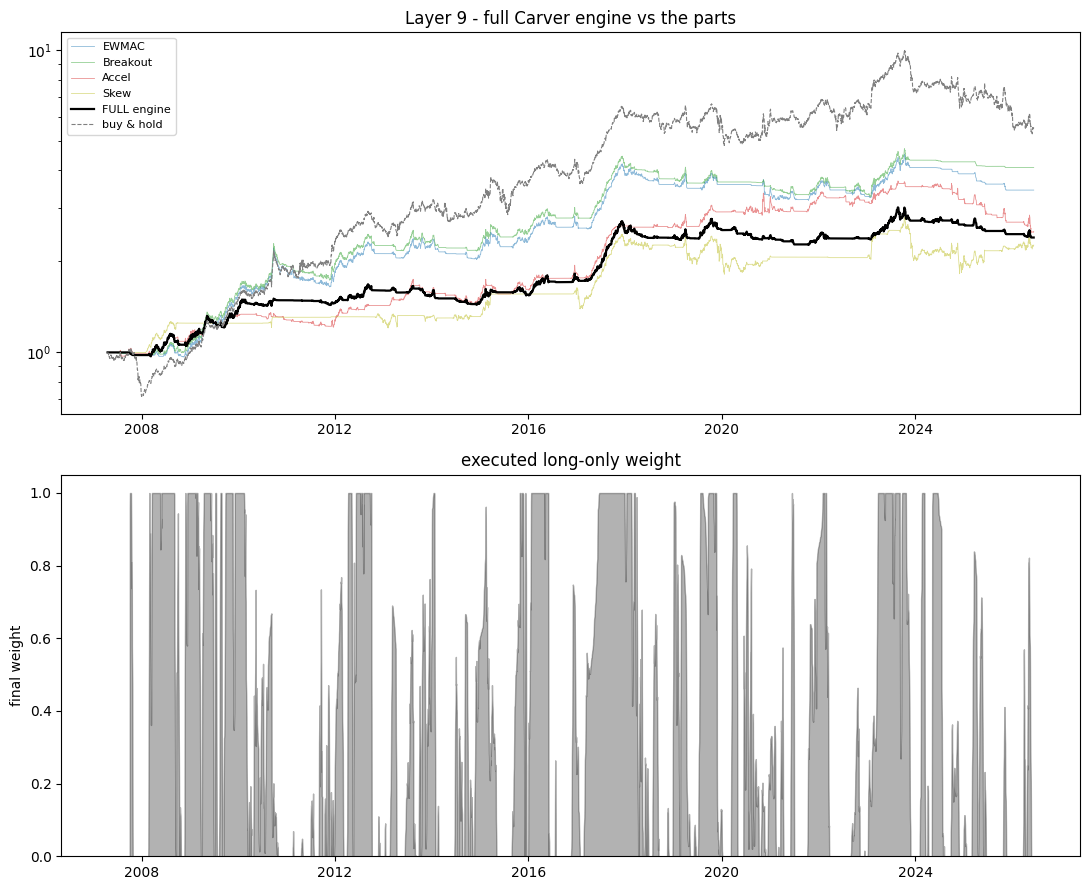

In [15]:
def full_carver(close, use_fti=True):
    vs = vol_stack(close)
    ew = ewmac_forecast(close, vs.sigma_p)
    br = breakout_forecast(close)
    ac = accel_forecast(close, vs.sigma_p)
    sk = skew_forecast(vs.ret)
    fc_att = clip_fc(combine_forecasts(ew, br, ac, sk) * vol_attenuation(vs.vol))
    w = position_from_forecast(fc_att, vs.vol, long_only=True)
    if use_fti:
        mult, _ = fti_multiplier(close)
        w = (w * mult).clip(0, 1)
    return w

w_full  = full_carver(close, use_fti=True)
w_nofti = full_carver(close, use_fti=False)
res_full, res_nofti = backtest(close, w_full), backtest(close, w_nofti)

print("=" * 78)
report("Buy & hold", backtest(close, pd.Series(1.0, index=close.index)))
for k, r in {"EWMAC": res_ew, "Breakout": res_br, "Accel": res_ac, "Skew": res_sk}.items(): report(k, r)
report("FULL engine (no FTI)", res_nofti)
report("FULL engine (with FTI)", res_full)

fig, ax = plt.subplots(2, 1, figsize=(11, 9))
for k, r, c in [("EWMAC", res_ew, "tab:blue"), ("Breakout", res_br, "tab:green"),
                ("Accel", res_ac, "tab:red"), ("Skew", res_sk, "tab:olive")]:
    ax[0].plot(r.index, r.equity, lw=0.6, alpha=0.5, color=c, label=k)
ax[0].plot(res_full.index, res_full.equity, "k", lw=1.6, label="FULL engine")
ax[0].plot(bh.index, bh, color="gray", lw=0.8, ls="--", label="buy & hold")
ax[0].set_yscale("log"); ax[0].legend(fontsize=8); ax[0].set_title("Layer 9 - full Carver engine vs the parts")
ax[1].fill_between(w_full.index, 0, w_full, color="k", alpha=0.3)
ax[1].set_ylim(0, 1.05); ax[1].set_ylabel("final weight"); ax[1].set_title("executed long-only weight")
plt.tight_layout(); plt.show()

**Where to take it next:** swap in real QQQ (`pip install yfinance`),
then re-fit each scalar to QQQ daily using its calibration line, re-measure the
correlation matrix on active periods, and decide the cross-rule FDM from those
correlations rather than letting it be eaten by the weight-sum. Everything is
one function (`full_carver`) so you can A/B those choices directly.